In [297]:
import torch
import matplotlib.pyplot as plt

n_disc = 1000
t = torch.linspace(0, 10, n_disc)

c_0 = torch.zeros_like(t)
c_0[t > 2.5] = 1

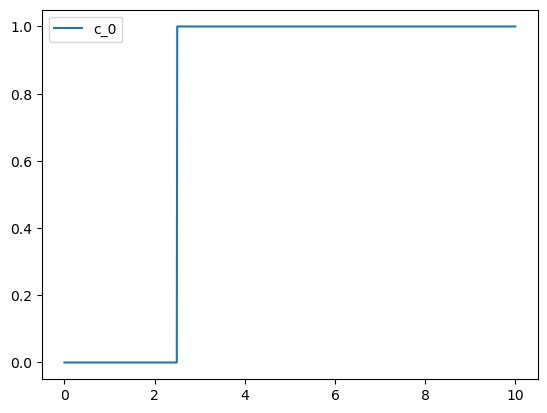

In [298]:
plt.plot(t, c_0, label="c_0")
plt.legend()
plt.show()

Now we need the convolution. We start simple by just performing any convolution:

In [299]:
n_kernel = 400
t_kernel = torch.linspace(0, 10, n_kernel)
conv = torch.nn.Conv1d(
    1, 1, n_kernel, bias=False, padding=n_kernel - 1, padding_mode="replicate"
)
# conv = torch.nn.Conv1d(1, 1, n_kernel, bias=False, padding=n_kernel, padding_mode="zeros"

E_guess = conv.get_parameter("weight")

c = conv(c_0[None, :])

t_c = torch.linspace(2 * t[0], 2 * t[-1], n_disc + n_kernel + 1)

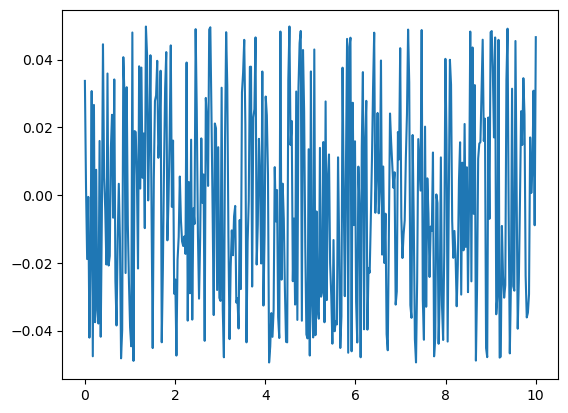

In [300]:
plt.plot(t_kernel, E_guess[0, 0, :].detach().numpy(), label="E_guess")

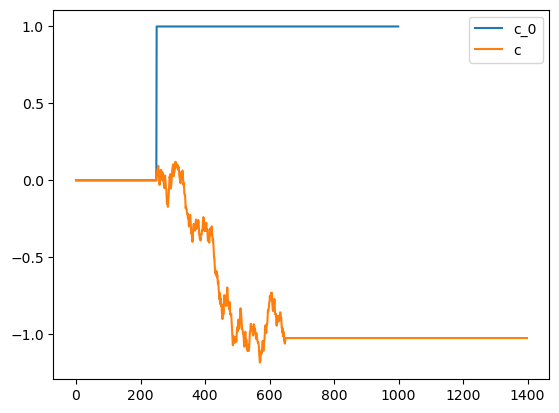

In [301]:
plt.plot(c_0, label="c_0")
plt.plot(c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()

In [302]:
c.shape

torch.Size([1, 1399])

ValueError: x and y must have same first dimension, but have shapes torch.Size([1401]) and (1399,)

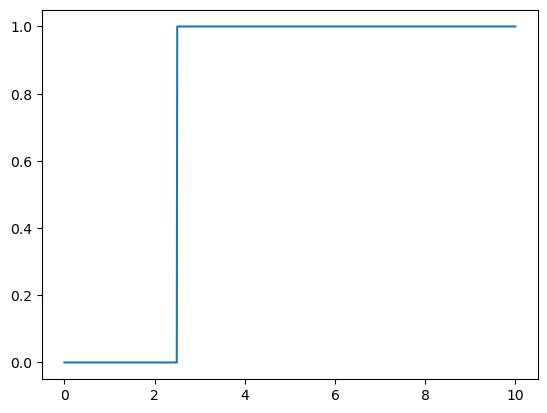

In [303]:
plt.plot(t, c_0, label="c_0")
plt.plot(t_c, c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()

okay, not bad, it has done something

Now lets investigate. We supply a RTD we know and can derive, what the corresponding c(t) would look like.

Therefore we first need to figure out the actual shape of the convolved kernel.

In [ ]:
list(conv.parameters())[0].shape

torch.Size([1, 1, 400])

In [ ]:
list(conv.parameters())

[Parameter containing:
 tensor([[[ 2.6620e-02, -4.5440e-03, -4.6367e-02, -3.3397e-02, -1.4406e-02,
           -3.0273e-03,  2.1611e-02, -1.9247e-02, -2.3285e-02, -4.5063e-02,
            8.6326e-03,  2.2672e-02, -4.9326e-02,  4.3387e-02,  1.7586e-02,
           -3.6030e-02,  1.1427e-02, -3.3053e-02,  8.5132e-03,  2.7002e-02,
           -1.4209e-02,  7.0702e-03, -1.7748e-02, -3.4183e-02, -1.4742e-02,
           -6.9302e-05, -3.8804e-02,  3.9963e-02, -4.3542e-02, -3.1348e-02,
            4.3416e-02, -3.6126e-02,  6.0596e-03,  4.1029e-02,  6.1035e-03,
            3.2809e-02, -1.1100e-02,  4.8593e-02,  2.6890e-02,  1.0887e-03,
            3.1411e-02,  3.4495e-02, -3.5062e-03, -2.2600e-02, -2.9618e-02,
           -1.0854e-02, -2.2170e-03,  9.6299e-03, -2.8232e-02,  1.1478e-02,
            1.0609e-04,  3.8538e-02,  3.1719e-02,  3.3222e-02, -4.3027e-02,
           -1.6226e-02, -3.5546e-02, -4.4959e-02,  2.0938e-02, -4.7971e-02,
           -4.1554e-02, -6.5521e-04,  2.3447e-02, -1.9177e-02, -3

This is the kernel. lets build our own kernel:

In [ ]:
E_guess.data = torch.zeros_like(E_guess.data)
E_guess.data[0, 0, 100:200] = 0.1

In [ ]:
c = conv(c_0[None, :])

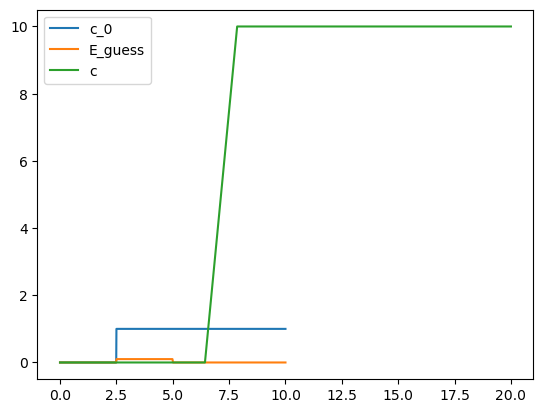

In [ ]:
plt.plot(t, c_0, label="c_0")
plt.plot(t_kernel, E_guess[0, 0, :].detach().numpy(), label="E_guess")
plt.plot(t_c, c[0, :].detach().numpy(), label="c")
plt.legend()
plt.show()